# Q2: Denoising score matching
### Amir Kooshan Fattah Hesari - 401102191

## Theory

### Problem 1: Implicit score matching

The objective of score matching is
$$
    \frac{1}{2} \mathbb{E}_{\pi}\bigl\| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}) - \nabla_\mathbf{x} \log \pi(\mathbf{x}) \bigr\|^2_2 \rightarrow \min_{\boldsymbol{\theta}}.
$$

And we have already known one possible solution for this task. It is denoising score matching.

Here our goal is to derive one more way to solve the initial score matching problem. It is called **implicit score matching**.

Let consider 1-d case ($x \in \mathbb{R}$).
Prove that
$$
\frac{1}{2} \mathbb{E}_{\pi}\bigl\| s_{\boldsymbol{\theta}}(x) - \nabla_x \log \pi(x) \bigr\|^2_2 = \mathbb{E}_{\pi}\left[ \frac{1}{2}s^2_{\boldsymbol{\theta}}(x) + \nabla_{x} s_{\boldsymbol{\theta}}(x) \right] + \text{const}.
$$

- **Question:** Why is the expression at the right hand side better than the left one?
 - **It removes the unknown “true score.”**  
    The left-hand-side objective compares your model’s score to the true score of the data distribution. But in most real problems you *don’t know* the data density in a form you can differentiate, so the true score is not available.  
    The right-hand-side objective rewrites the same goal so that the unknown score disappears, leaving only:
    - samples from the data distribution, and
    - quantities you can compute from your model (its output and how that output changes when the input changes).
  - **It becomes trainable from samples alone.**  
    With only data points, you can estimate averages over the data distribution. The right-hand-side is exactly an average of model-computable terms, plus a constant that does not depend on the parameters (so it doesn’t affect the optimizer).  
    This is why it is called **implicit**: you learn the score without ever explicitly computing the true score.


- **Question:** Why do we not use this expression instead of denoising score matching?
- **It needs input-derivatives of the model during training.**  
    The implicit objective contains a term that depends on how the model output changes with respect to the input. For neural networks, training then requires differentiating through that term to update parameters, which often leads to:
    - higher computational cost,
    - more memory use,
    - and in many setups, effectively “second-order” derivatives.
  - **It is especially painful in high dimensions.**  
    In multiple dimensions, the needed derivative term becomes a “sum of partial derivatives” across all input coordinates. Computing that exactly is expensive when the input is large (images, audio, etc.).  
    People use stochastic tricks to approximate it, but those approximations:
    - add variance (noisier gradients),
    - introduce extra hyperparameters and randomness,
    - and can make training less stable.
  - **Denoising score matching is usually simpler and more scalable.**  
    Denoising methods add known noise to data and turn training into a clean supervised problem: the target comes from the noise process you chose, so you avoid computing those expensive derivative/trace terms.  
    In practice, this tends to be:
    - easier to implement,
    - faster,
    - more numerically stable,
    - and better suited to large neural networks and high-dimensional data.



- **Question:** Why do we consider only 1-d case?
 - **The proof idea is simplest in 1-D.**  
    The key step is an “integration by parts” argument. In one dimension, this is basic calculus and is easy to follow.
  - **The multi-dimensional version is conceptually the same but notationally heavier.**  
    In higher dimensions you use the divergence theorem (a multi-dimensional generalization of integration by parts). The result looks similar, but the derivative term becomes more complex and is exactly the part that is expensive in practice.
  - **So 1-D is mainly for clarity, not because the method only works in 1-D.**  
    The method generalizes, but the computational burden grows quickly with dimensionality—one of the main reasons denoising approaches dominate in modern high-dimensional applications.




### Problem 2: Conditioned reverse distribution for NCSN

The distribution $q(\mathbf{x}_{t-1} | \mathbf{x}_t, \mathbf{x}_0)$ plays the crucial role in the DDPM.

Find the parameters of this Normal distribution for the NCSN Markov chain $\mathbf{x}_t = \mathbf{x}_0 + \sigma_t \cdot \boldsymbol{\epsilon}$.

**Note:** in this case the mean should be the convex combination of $\mathbf{x}_t$ and $\mathbf{x}_0$ (this differs from the DDPM Markov chain).

```
your solution
```

$$
q(\mathbf{x}_t \mid \mathbf{x}_{t-1})
= \mathcal{N}\!\left(\mathbf{x}_{t-1},\,(\sigma_t^2-\sigma_{t-1}^2)\mathbf{I}\right),
\qquad
q(\mathbf{x}_{t-1} \mid \mathbf{x}_0)
= \mathcal{N}\!\left(\mathbf{x}_0,\,\sigma_{t-1}^2\mathbf{I}\right).
$$

$$
q(\mathbf{x}_{t-1} \mid \mathbf{x}_t,\mathbf{x}_0)
= \mathcal{N}\!\left(\tilde{\boldsymbol{\mu}}(\mathbf{x}_t,\mathbf{x}_0),\,\tilde{\boldsymbol{\Sigma}}_t\right),
$$

$$
\tilde{\boldsymbol{\mu}}(\mathbf{x}_t,\mathbf{x}_0)
=
\frac{\sigma_{t-1}^2}{\sigma_t^2}\,\mathbf{x}_t
+
\left(1-\frac{\sigma_{t-1}^2}{\sigma_t^2}\right)\mathbf{x}_0
=
\frac{\sigma_{t-1}^2}{\sigma_t^2}\,\mathbf{x}_t
+
\frac{\sigma_t^2-\sigma_{t-1}^2}{\sigma_t^2}\,\mathbf{x}_0.
$$

$$
\tilde{\boldsymbol{\Sigma}}_t
=
\frac{\sigma_{t-1}^2(\sigma_t^2-\sigma_{t-1}^2)}{\sigma_t^2}\,\mathbf{I}.
$$


In [1]:
import numpy as np
from typing import Tuple, List
import math

import torch
import torch.nn as nn
import torch.utils.data as data
from torch.nn import functional as F

if torch.cuda.is_available():
    DEVICE = "cuda"
    print('GPU found :)')
else:
    DEVICE = "cpu"
    print('GPU not found :(')

GPU found :)


# NOTE: Don't change this part

In [2]:
from typing import Dict, List, Literal, Optional, Tuple
from collections import defaultdict
from IPython.display import clear_output

import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.optimizer import Optimizer
from torch.optim.lr_scheduler import LRScheduler

import torchvision
from torchvision.utils import make_grid
from sklearn.datasets import make_moons



TICKS_FONT_SIZE = 12
LEGEND_FONT_SIZE = 12
LABEL_FONT_SIZE = 14
TITLE_FONT_SIZE = 16

TOY_DATASETS = ["moons"]
IMAGE_DATASETS = ["mnist", "cifar10"]

def prepare_images(
    train_data: np.ndarray,
    test_data: np.ndarray,
    flatten: bool = False,
    binarize: bool = True
) -> Tuple[np.ndarray, np.ndarray]:
    if binarize:
        train_data = (train_data > 128).astype("int64")
        test_data = (test_data > 128).astype("int64")
    else:
        train_data = train_data / 255.0
        test_data = test_data / 255.0

    train_data = np.transpose(train_data, (0, 3, 1, 2))
    test_data = np.transpose(test_data, (0, 3, 1, 2))

    if flatten:
        train_data = train_data.reshape(len(train_data.shape[0]), -1)
        test_data = test_data.reshape(len(train_data.shape[0]), -1)

    return train_data, test_data

def load_MNIST(with_targets: bool = False) -> Tuple[np.ndarray, Optional[np.ndarray], np.ndarray, Optional[np.ndarray]]:
    train_dataset = torchvision.datasets.MNIST(root="./", train=True, download=True)
    test_dataset = torchvision.datasets.MNIST(root="./", train=False, download=True)

    transform = torchvision.transforms.Resize((32, 32))
    train_data = torch.stack([transform(img.unsqueeze(0)) for img in train_dataset.data]).numpy().transpose(0, 2, 3, 1)
    test_data = torch.stack([transform(img.unsqueeze(0)) for img in test_dataset.data]).numpy().transpose(0, 2, 3, 1)

    if with_targets:
        train_labels, test_labels = train_dataset.targets.numpy(), test_dataset.targets.numpy()
        return train_data, train_labels, test_data, test_labels

    return train_data, None, test_data, None


def load_CIFAR10(with_targets: bool = False) -> Tuple[np.ndarray, Optional[np.ndarray], np.ndarray, Optional[np.ndarray]]:
    train_dataset = torchvision.datasets.CIFAR10(root="./", train=True, download=True)
    test_dataset = torchvision.datasets.CIFAR10(root="./", train=False, download=True)
    train_data, test_data = train_dataset.data, test_dataset.data

    if with_targets:
        train_labels, test_labels = (
            train_dataset.targets.numpy(),
            test_dataset.targets.numpy(),
        )
        return train_data, train_labels, test_data, test_labels

    return train_data, None, test_data, None

def load_moons(
    size: int,
    with_targets: bool
) -> Tuple[np.ndarray, Optional[np.ndarray], np.ndarray, Optional[np.ndarray]]:
    data, labels = make_moons(n_samples=size, noise=0.1)
    split = int(0.8 * size)
    train_data, test_data = data[:split], data[split:]

    if with_targets:
        train_labels, test_labels = labels[:split], labels[split:]
        return train_data, train_labels, test_data, test_labels

    return train_data, None, test_data, None


def _load_dataset(
    name: Literal["mnist", "cifar10", "moons"],
    size: Optional[int] = None,
    with_targets: bool = False,
) -> Tuple[np.ndarray, Optional[np.ndarray], np.ndarray, Optional[np.ndarray]]:
    if name == "mnist":
        return load_MNIST(with_targets=with_targets)
    elif name == "cifar10":
        return load_CIFAR10(with_targets=with_targets)
    elif name == "moons":
        if size is None:
            raise ValueError("Size must be specifed for 'moons' dataset!")
        return load_moons(size=size, with_targets=with_targets)
    else:
        raise ValueError("The argument name must have the values 'mnist', 'cifar10' or 'moons'!")


def load_dataset(
    name: str,
    size: Optional[int] = None,
    flatten: bool = False,
    binarize: bool = True,
    with_targets: bool = False
) -> Tuple[np.ndarray, Optional[np.ndarray], np.ndarray, Optional[np.ndarray]]:

    train_data, train_labels, test_data, test_labels = _load_dataset(
        name, size=size,
        with_targets=with_targets
    )
    train_data = train_data.astype("float32")
    test_data = test_data.astype("float32")

    if name in IMAGE_DATASETS:
        train_data, test_data = prepare_images(
            train_data,
            test_data,
            flatten=flatten,
            binarize=binarize
        )

    if with_targets:
        return train_data, train_labels, test_data, test_labels

    return train_data, test_data

class LabeledDataset(Dataset):
    def __init__(self, data, labels):
        super().__init__()
        self.data = data
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.labels[idx]
        return x, y


def plot_training_curves(
    epochs: int,
    train_losses: Dict[str, List[float]],
    test_losses: Optional[Dict[str, List[float]]],
    logscale_y: bool = False,
    logscale_x: bool = False,
) -> None:
    if test_losses is not None:
        n_test = len(test_losses[list(train_losses.keys())[0]])
        x_test = np.arange(n_test)

    n_train = len(train_losses[list(train_losses.keys())[0]])
    x_train = np.linspace(0, epochs - 1, n_train)


    plt.figure()
    for key, value in train_losses.items():
        plt.plot(x_train, value, label=key + "_train")

    if test_losses is not None:
        for key, value in test_losses.items():
            plt.plot(x_test, value, label=key + "_test")

    if logscale_y:
        plt.semilogy()

    if logscale_x:
        plt.semilogx()

    plt.legend(fontsize=LEGEND_FONT_SIZE)
    plt.xlabel("Epoch", fontsize=LABEL_FONT_SIZE)
    plt.ylabel("Loss", fontsize=LABEL_FONT_SIZE)
    plt.xticks(fontsize=TICKS_FONT_SIZE)
    plt.yticks(fontsize=TICKS_FONT_SIZE)
    plt.grid()
    plt.show()


def show_samples(
    samples: np.ndarray | torch.Tensor,
    title: str,
    figsize: Optional[Tuple[int, int]] = None,
    nrow: Optional[int] = None,
    normalize: bool = False
) -> None:
    if isinstance(samples, np.ndarray):
        samples = torch.tensor(samples)
    if nrow is None:
        nrow = int(np.sqrt(len(samples)))

    grid_samples = make_grid(samples, nrow=nrow, normalize=normalize, scale_each=True)
    grid_img = grid_samples.permute(1, 2, 0)

    plt.figure(figsize=(6, 6) if figsize is None else figsize)
    plt.title(title, fontsize=TITLE_FONT_SIZE)
    plt.imshow(grid_img)
    plt.axis("off")
    plt.show()


def visualize_images(data: np.ndarray, title: str) -> None:
    idxs = np.random.choice(len(data), replace=False, size=(100,))
    images = data[idxs]
    show_samples(images, title)


def visualize_2d_data(
    train_data: np.ndarray,
    test_data: np.ndarray,
    train_labels: Optional[str] = None,
    test_labels: Optional[str] = None,
    s: int = 10
) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.set_title("train", fontsize=TITLE_FONT_SIZE)
    ax1.scatter(train_data[:, 0], train_data[:, 1], s=s, c=train_labels)
    ax1.tick_params(labelsize=LABEL_FONT_SIZE)
    ax2.set_title("test", fontsize=TITLE_FONT_SIZE)
    ax2.scatter(test_data[:, 0], test_data[:, 1], s=s, c=test_labels)
    ax2.tick_params(labelsize=LABEL_FONT_SIZE)
    plt.show()


def visualize_2d_samples(
    data: np.ndarray,
    title: str,
    labels: Optional[str] = None,
    xlabel: str = "x1",
    ylabel: str = "x2",
    s: int = 10
) -> None:
    plt.figure(figsize=(5, 5))
    plt.scatter(data[:, 0], data[:, 1], s=s, c=labels)
    plt.title(title, fontsize=TITLE_FONT_SIZE)
    plt.xticks(fontsize=TICKS_FONT_SIZE)
    plt.yticks(fontsize=TICKS_FONT_SIZE)
    if xlabel is not None:
        plt.xlabel(xlabel, fontsize=LABEL_FONT_SIZE)
    if ylabel is not None:
        plt.ylabel(ylabel, fontsize=LABEL_FONT_SIZE)
    plt.show()


def visualize_2d_densities(
    x_grid: np.ndarray,
    y_grid: np.ndarray,
    densities: np.ndarray,
    title: str,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
) -> None:
    densities = densities.reshape([y_grid.shape[0], y_grid.shape[1]])
    plt.figure(figsize=(5, 5))
    plt.pcolor(x_grid, y_grid, densities)
    plt.pcolor(x_grid, y_grid, densities)

    plt.title(title, fontsize=TITLE_FONT_SIZE)
    plt.xticks(fontsize=TICKS_FONT_SIZE)
    plt.yticks(fontsize=TICKS_FONT_SIZE)
    if xlabel is not None:
        plt.xlabel(xlabel, fontsize=LABEL_FONT_SIZE)
    if ylabel is not None:
        plt.ylabel(ylabel, fontsize=LABEL_FONT_SIZE)
    plt.show()



class BaseModel(nn.Module):
    def __init__(self) -> None:
        super().__init__()

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError('Not implemented')

    def loss(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        raise NotImplementedError('Not implemented')

    @torch.no_grad()
    def sample(self, n: int) -> np.ndarray:
        raise NotImplementedError('Not implemented')

def train_model(
    model: BaseModel,
    train_loader: DataLoader,
    test_loader: DataLoader,
    epochs: int,
    optimizer: Optimizer,
    scheduler: Optional[LRScheduler] = None,
    conditional: bool = False,
    loss_key: str = "total_loss",
    n_samples: int = 100,
    visualize_samples: bool = True,
    logscale_y: bool = False,
    logscale_x: bool = False,
    device: str = "cpu",
):

    train_losses: Dict[str, List[float]] = defaultdict(list)
    test_losses: Dict[str, List[float]] = defaultdict(list)
    model = model.to(device)
    print("Start of the training")

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(
            epoch, model, train_loader, optimizer, conditional, device, loss_key
        )
        if scheduler is not None:
            scheduler.step()
        test_loss = eval_model(epoch, model, test_loader, conditional, device)

        for k in train_loss.keys():
            train_losses[k].extend(train_loss[k])
            test_losses[k].append(test_loss[k])

        epoch_loss = np.mean(train_loss[loss_key])
        if visualize_samples:
            with torch.no_grad():
                samples = model.sample(n_samples)
                if isinstance(samples, torch.Tensor):
                    samples = samples.cpu().detach().numpy()

            clear_output(wait=True)
            title = f"Samples, epoch: {epoch}, {loss_key}: {epoch_loss:.3f}"
            if check_samples_is_2d(samples):
                visualize_2d_samples(samples, title=title)
            else:
                show_samples(samples, title=title)
            plot_training_curves(epoch, train_losses, test_losses, logscale_y, logscale_x)
        else:
            clear_output(wait=True)
            print(f"Epoch: {epoch}, loss: {epoch_loss}")
            plot_training_curves(epoch, train_losses, test_losses, logscale_y, logscale_x)

    print("End of the training")


## Task 2: Denoising score matching for 2D data

In this task you will implement the denoising score matching model to the 2D moons dataset.

Let's take a look at dataset samples.

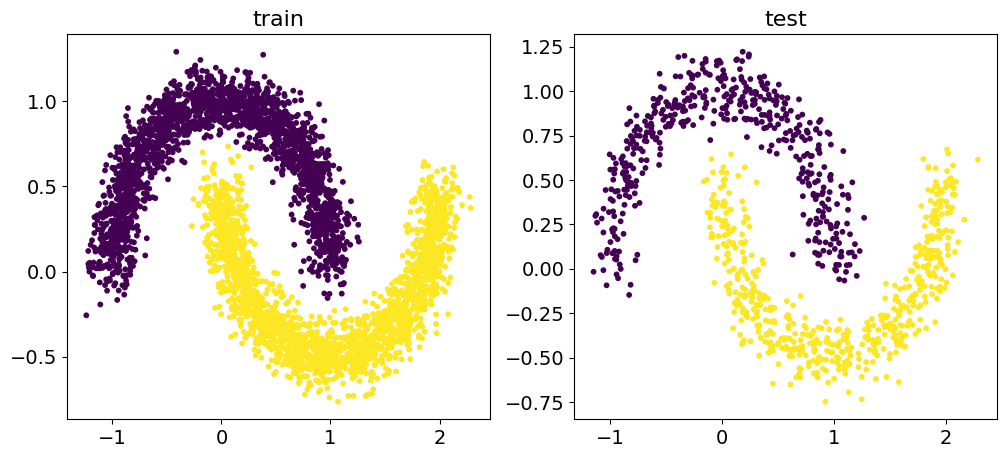

In [3]:
COUNT = 5000

train_data, train_labels, test_data, test_labels = load_dataset('moons', size=COUNT, with_targets=True)
visualize_2d_data(train_data, test_data, train_labels, test_labels)

Let recall the theory of denoising score matching.

The idea is the following. We define the score function
$$
    \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}) = \nabla_{\mathbf{x}}\log p(\mathbf{x}| \boldsymbol{\theta}).
$$

Then we minimize the Fisher divergence to obtain the score function:
$$
    D_F(\pi, p) = \frac{1}{2}\mathbb{E}_{\pi}\bigl\| \mathbf{s}_{\boldsymbol{\theta}}(\mathbf{x}) - \nabla_{\mathbf{x}} \log \pi(\mathbf{x}) \bigr\|^2_2 \rightarrow \min_{\boldsymbol{\theta}}
$$.

If we had the score function, we could use the Langevin dynamics to sample from our model:
$$
    \mathbf{x}_{l + 1} = \mathbf{x}_l + \frac{\eta}{2} \cdot \nabla_{\mathbf{x}_l} \log p(\mathbf{x}_l | \boldsymbol{\theta}) + \sqrt{\eta} \cdot \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(0, \mathbf{I}).
$$

However, Fisher divergence is intractable and we use the noising procedure to get noised samples $\mathbf{x}_{\sigma} = \mathbf{x} + \sigma \cdot \boldsymbol{\epsilon}$.

Minimizing the Fisher divergence for the noisy samples is equivalent to the following objective:
$$
\mathbb{E}_{q(\mathbf{x}_{\sigma})}\bigl\| \mathbf{s}_{\boldsymbol{\theta}, \sigma}(\mathbf{x}_{\sigma}) - \nabla_{\mathbf{x}_{\sigma}} \log q(\mathbf{x}_{\sigma}) \bigr\|^2_2 = \mathbb{E}_{\pi(\mathbf{x})} \mathbb{E}_{q(\mathbf{x}_{\sigma} | \mathbf{x})}\bigl\| \mathbf{s}_{\boldsymbol{\theta}, \sigma}(\mathbf{x}_{\sigma}) - \nabla_{\mathbf{x}_{\sigma}} \log q(\mathbf{x}_{\sigma} | \mathbf{x}) \bigr\|^2_2 + \text{const}(\boldsymbol{\theta}).
$$

Here
$$
    \log q(\mathbf{x}_{\sigma} | \mathbf{x}) = - \frac{\mathbf{x}_{\sigma} - \mathbf{x}}{\sigma^2} = - \frac{\boldsymbol{\epsilon}}{\sigma}.
$$

Therefore, the objective of the denoising score matching is

$$
\mathbb{E}_{\pi(\mathbf{x})} \mathbb{E}_{q(\mathbf{x}_{\sigma} | \mathbf{x})}\bigl\| \mathbf{s}_{\boldsymbol{\theta}, \sigma}(\mathbf{x}_{\sigma}) + \frac{\boldsymbol{\epsilon}}{\sigma} \bigr\|^2_2 \rightarrow \min_{\boldsymbol{\theta}}.
$$

In [4]:
class DenoisingScoreMatcher(BaseModel):
    def __init__(
        self,
        score_model: nn.Module,
        input_shape: Tuple[int],
        sigma: float
    ):
        super().__init__()
        self.score_model = score_model
        self.input_shape = input_shape
        self.sigma = sigma

    def forward(self, x: torch.Tensor):
        # sample gaussian noise
        eps = torch.randn_like(x)

        # perturb samples using the noise and sigma
        noisy_x = x + self.sigma * eps

        # calculate the score model
        s = self.score_model(noisy_x)

        # gradient of log N(noisy_x; mean=x, var=sigma^2 I) w.r.t. noisy_x
        # = -(noisy_x - x) / sigma^2 = -eps / sigma
        target = -eps / self.sigma

        # mse between score function and the gradient (keep per-dimension loss)
        loss = (s - target) ** 2
        return loss

    def loss(self, x: torch.Tensor):
        return {"total_loss": self(x).mean(dim=0).sum()}

    def langevin_dynamics(self, x: torch.Tensor, num_steps: int, eta: float):
        for _ in range(num_steps):
            z = torch.randn_like(x)
            x = x + eta * self.score_model(x) + (2.0 * eta) ** 0.5 * z
        return x

    def sample(self, num_samples: int = 64, num_steps: int = 100, eta: float = 0.01):
        with torch.no_grad():
            # we sample x_0 from U[-1, 1]
            x0 = 2.0 * torch.rand_like(torch.empty(num_samples, *self.input_shape)) - 1.0
            x0 = x0.to(self.device)

            # run langevin dynamics
            x = self.langevin_dynamics(x0, num_steps=num_steps, eta=eta)
        return x


def test_denoiser_score_matcher():
    matcher = DenoisingScoreMatcher(
        score_model=nn.Linear(2, 2),
        input_shape=(2,),
        sigma=0.1
    )
    x = torch.rand(16, 2)
    assert x.size() == matcher(x).size()
    loss = matcher.loss(x)["total_loss"]
    assert len(loss.size()) == 0
    assert list(matcher.sample(4).size()) == [4, 2]


test_denoiser_score_matcher()

That's all!

And now we are ready to train our model.

In [17]:
from contextlib import nullcontext
def train_epoch(
    epoch: int,
    model: torch.nn.Module, 
    train_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    gradient_clip_val: Optional[float] = None,
    conditional: bool = False,
    device: str = "cpu",
    loss_key: str = "total_loss",
    use_amp: bool = False,
    scaler: Optional[torch.amp.GradScaler] = None,
) -> Dict[str, List[float]]:
    model.train()
    stats: Dict[str, List[float]] = defaultdict(list)
    
    for batch in tqdm(train_loader, desc=f"Training epoch {epoch}"):
        if conditional:
            x, y = batch
            x, y = x.to(device), y.to(device)
        else:
            if isinstance(batch, (list, tuple)):
                x = batch[0].to(device)
                y = None
            else:
                x, y = batch.to(device), None
                
        optimizer.zero_grad()
        ctx = torch.amp.autocast("cuda") if use_amp else nullcontext()
        
        with ctx:
            losses = model.loss(x, y) if y is not None else model.loss(x)
            loss = losses[loss_key]

        if use_amp and scaler is not None:
            scaler.scale(loss).backward()
            if gradient_clip_val is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip_val)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if gradient_clip_val is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip_val)
            optimizer.step()

        for k, v in losses.items():
            stats[k].append(v.item())

    return stats

def eval_model(
    epoch: int,
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    conditional: bool = False,
    device: str = "cpu",
    use_amp: bool = False,
) -> Dict[str, float]:
    model.eval()
    stats: Dict[str, float] = defaultdict(float)
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc=f"Evaluating epoch {epoch}"):
            if conditional:
                x, y = batch
                x, y = x.to(device), y.to(device)
            else:
                if isinstance(batch, (list, tuple)):
                    x = batch[0].to(device)
                    y = None
                else:
                    x, y = batch.to(device), None
            
            ctx = torch.amp.autocast("cuda") if use_amp else nullcontext()
            with ctx:
                losses = model.loss(x, y) if y is not None else model.loss(x)
                
            for k, v in losses.items():
                stats[k] += v.item() * x.shape[0]

        for k in stats.keys():
            stats[k] /= len(data_loader.dataset)
            
    return stats

def check_samples_is_2d(samples: np.ndarray) -> bool:
    shape = samples.shape
    return len(shape) == 2 and shape[1] == 2
def train_model(
    model: BaseModel,
    train_loader: DataLoader,
    test_loader: DataLoader,
    epochs: int,
    optimizer: Optimizer,
    scheduler: Optional[LRScheduler] = None,
    gradient_clip_val: Optional[float] = None,
    conditional: bool = False,
    loss_key: str = "total_loss",
    n_samples: int = 100,
    visualize_samples: bool = True,
    logscale_y: bool = False,
    logscale_x: bool = False,
    device: str = "cpu",
    use_amp: bool = False,
) -> None:
    """
    Train a generative model with visualization.
    
    Args:
        model: The model to train.
        train_loader: DataLoader for training data.
        test_loader: DataLoader for test data.
        epochs: Number of training epochs.
        optimizer: Optimizer for updating model parameters.
        scheduler: Optional learning rate scheduler.
        gradient_clip_val: Optional gradient norm clipping value.
        conditional: Whether the model is conditional (expects (x, y) batches).
        loss_key: Key in the loss dict to use for backpropagation.
        n_samples: Number of samples to generate for visualization.
        visualize_samples: Whether to visualize generated samples during training.
        logscale_y: Whether to use log scale for y-axis in loss plots.
        logscale_x: Whether to use log scale for x-axis in loss plots.
        device: Device to train on ("cpu" or "cuda").
        use_amp: Whether to use automatic mixed precision.
    """
    train_losses: Dict[str, List[float]] = defaultdict(list)
    test_losses: Dict[str, List[float]] = defaultdict(list)
    model = model.to(device)
    print("Start of the training")

    scaler = torch.amp.GradScaler("cuda") if use_amp else None
    test_loss = eval_model(0, model, test_loader, conditional, device)
    for k in test_loss.keys():
        test_losses[k].append(test_loss[k])

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(
            epoch, model, train_loader, optimizer, gradient_clip_val, conditional, device, loss_key, use_amp, scaler
        )
        if scheduler is not None:
            scheduler.step()
        test_loss = eval_model(epoch, model, test_loader, conditional, device, use_amp)

        for k in train_loss.keys():
            train_losses[k].extend(train_loss[k])
        for k in test_loss.keys():
            test_losses[k].append(test_loss[k])

        epoch_loss = np.mean(train_loss[loss_key])
        if visualize_samples:
            with torch.no_grad():
                samples = model.sample(n_samples)
                if isinstance(samples, torch.Tensor):
                    samples = samples.cpu().detach().numpy()

            clear_output(wait=True)
            title = f"Samples, epoch: {epoch}, {loss_key}: {epoch_loss:.3f}"
            if check_samples_is_2d(samples):
                visualize_2d_samples(samples, title=title)
            else:
                show_samples(samples, title=title)
            plot_training_curves(epoch, train_losses, test_losses, logscale_y, logscale_x)
        else:
            clear_output(wait=True)
            print(f"Epoch: {epoch}, loss: {epoch_loss}")
            plot_training_curves(epoch, train_losses, test_losses, logscale_y, logscale_x)

    print("End of the training")

In [21]:
import math
import torch
from torch import nn

class FourierFeatures(nn.Module):
    """
    Fixed random Fourier features for 2D inputs.
    Helps MLPs represent curved / multi-modal structure (like moons) far better.
    """
    def __init__(self, in_dim=2, n_frequencies=128, scale=6.0):
        super().__init__()
        B = torch.randn(n_frequencies, in_dim) * scale
        self.register_buffer("B", B)

    def forward(self, x):
        # x: (B, 2)
        proj = (2 * math.pi) * (x @ self.B.t())  # (B, n_frequencies)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)  # (B, 2*n_frequencies)

class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, x):
        return x + self.block(x)

# Recommended defaults for moons
HIDDEN_SIZE = 256          # 256 is a sweet spot for moons
N_FREQ = 128               # 64–256 works; 128 is strong
FF_SCALE = 6.0             # 3–10; 6 is a good default

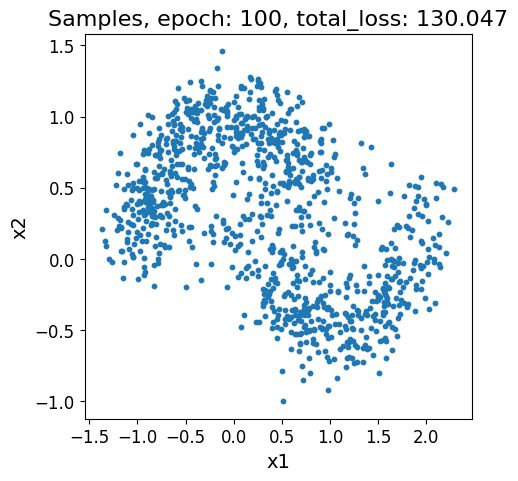

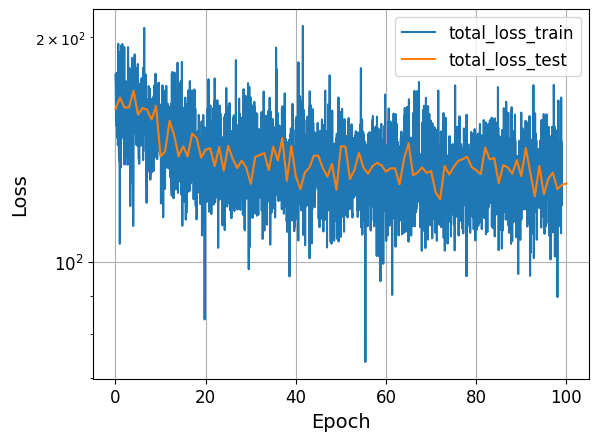

End of the training


In [30]:
# ====
# choose these parameters
BATCH_SIZE = 128
EPOCHS = 100
LR = 2e-3
HIDDEN_SIZE = 256
SIGMA = 0.13
# ====

train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)

# ====
# define sequential score model (2D -> 2D)

score_model = nn.Sequential(
    nn.Linear(2, HIDDEN_SIZE),
    nn.Softplus(),  
    nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
    nn.Softplus(),
    nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),
    nn.Softplus(),
    nn.Linear(HIDDEN_SIZE, 2)  
)
# ====

matcher = DenoisingScoreMatcher(
    score_model=score_model, input_shape=(2,), sigma=SIGMA
)

optimizer = torch.optim.Adam(matcher.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)

train_model(
    matcher,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    n_samples=1024,
    visualize_samples=True,
    logscale_y=True,
)


Let sample from our model. Experiment with number of steps and $\eta$ for Langevin dynamics.

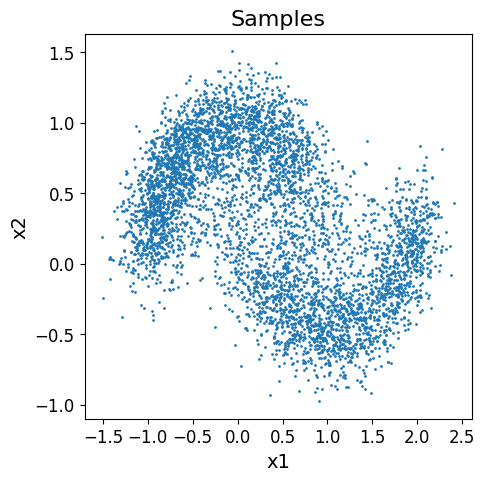

In [31]:
# ====
# your code
# choose these parameters
NUM_STEPS = 10000
ETA = 1e-2
# ====

samples = matcher.sample(num_samples=5000, num_steps=NUM_STEPS, eta=ETA).cpu()

visualize_2d_samples(samples, title="Samples", s=1)

## Noise Conditioned Score Network for MNIST

Now we try to extend our model to the NCSN. It means that we have to add multiple noise scales.

**Note!** Here we rescale the images to $[-1, 1]$, which will help us with training of the NCSN.

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


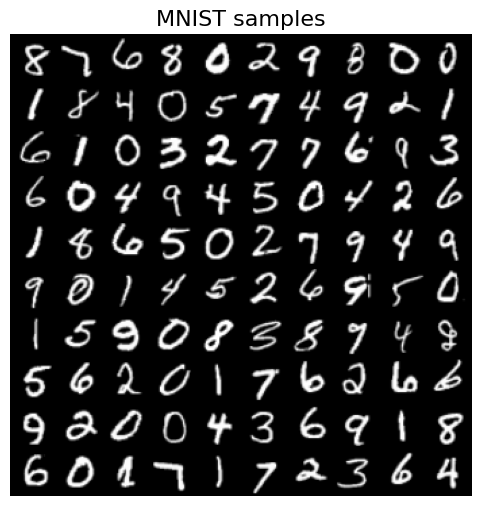

In [32]:
train_data, test_data = load_dataset("mnist", flatten=False, binarize=False)
visualize_images(train_data, "MNIST samples")

train_data, test_data = 2 * train_data - 1, 2 * test_data - 1


First, we'll define the UNet's core component. It is the `ResBlock`, which enhances standard ResNet blocks with timestep embeddings.

In [33]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, t_dim, dropout):
        super().__init__()
        self.temb_proj = nn.Sequential(nn.SiLU(), nn.Linear(t_dim, out_channels))

        # First block: normalize and convolve the raw input
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        )

        # Second block: normalize, activate, drop, then convolve after time embedding is added
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        )

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, temb):
        # 1) Pass input through the first convolutional block
        h = self.block1(x)

        # 2) Project and add time embedding — unsqueeze to match spatial dims (B, C, 1, 1)
        h = h + self.temb_proj(temb)[:, :, None, None]

        # 3) Pass through the second convolutional block
        h = self.block2(h)

        # 4) Add shortcut (residual) connection
        return h + self.shortcut(x)

The `DownsampleBlock` and `UpsampleBlock` implement the UNet's characteristic encoder-decoder structure, managing resolution changes as features flow through the network.

In [34]:
class DownsampleBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        # Strided convolution halves spatial dims while keeping channel count the same
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)

    def forward(self, input_tensor: torch.Tensor, *args) -> torch.Tensor:
        x = self.conv(input_tensor)
        return x


class UpsampleBlock(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        # Regular convolution to refine features after upsampling, no size change
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, input_tensor: torch.Tensor, *args) -> torch.Tensor:
        # 1) Double spatial dims with bilinear interpolation
        x = F.interpolate(input_tensor, scale_factor=2, mode="bilinear", align_corners=False)
        # 2) Refine the upsampled feature map
        x = self.conv(x)
        return x

Finally, we define the complete `UNet` - the neural network backbone of our diffusion model that handles both encoding and decoding with skip connections. Look at the code carefully.

In [35]:
class UNet(nn.Module):
    def __init__(
        self,
        num_timesteps: int,
        hidden_channels: int,
        channel_multipliers: List[int],
        num_blocks: int = 1,
        dropout: float = 0.1
    ):
        super().__init__()

        temb_dim = hidden_channels * 4
        self.time_embedding = nn.Embedding(num_timesteps, temb_dim)
        self.head = nn.Conv2d(1, hidden_channels, kernel_size=3, stride=1, padding=1)
        channel_list, curr_channels = [hidden_channels], hidden_channels

        # initialization of downsample blocks
        self.downsample_blocks = nn.ModuleList()
        for idx, scale in enumerate(channel_multipliers):
            out_channels = hidden_channels * scale
            is_last = (idx == len(channel_multipliers) - 1)

            # make multiple ResBlocks at each scale
            for _ in range(num_blocks):
                # at each channel_multipliers scale we add ResBlock
                # last block has attention
                self.downsample_blocks.append(
                    ResBlock(curr_channels, out_channels, temb_dim, dropout)
                )
                curr_channels = out_channels
                channel_list.append(curr_channels)

            # add downsample block if not last block
            if not is_last:
                self.downsample_blocks.append(DownsampleBlock(curr_channels))
                channel_list.append(curr_channels)

        # initialization of bottleneck block
        self.bottleneck = nn.ModuleList([
            ResBlock(curr_channels, curr_channels, temb_dim, dropout),
            ResBlock(curr_channels, curr_channels, temb_dim, dropout)
        ])

        # initialization of upsample blocks
        self.upsample_blocks = nn.ModuleList()
        for idx, scale in reversed(list(enumerate(channel_multipliers))):
            out_channels = hidden_channels * scale
            is_first, is_last = (idx == 0), (idx == len(channel_multipliers) - 1)

            # make multiple ResBlocks at each scale
            for _ in range(num_blocks + 1):
                # at each reverse channel_multipliers scale we add ResBlock
                # first block has attention
                self.upsample_blocks.append(
                    ResBlock(channel_list.pop() + curr_channels, out_channels, temb_dim, dropout)
                )

                curr_channels = out_channels

            # add upsample block if not last block
            if not is_first:
                self.upsample_blocks.append(UpsampleBlock(curr_channels))

        self.tail = nn.Sequential(
            nn.GroupNorm(8, curr_channels),
            nn.SiLU(),
            nn.Conv2d(curr_channels, 1, kernel_size=3, stride=1, padding=1)
        )

    def forward(self, x, t):
        temb = self.time_embedding(t)

        h = self.head(x)
        skip_connections = [h] # save intermediate results for skip connections

        # downsample
        for layer in self.downsample_blocks:
            h = layer(h, temb)
            skip_connections.append(h) # save intermediate results for skip connections

        # bottleneck
        for layer in self.bottleneck:
            h = layer(h, temb)

        # upsample
        for layer in self.upsample_blocks:
            if isinstance(layer, ResBlock): # apply skip connection
                skip_connection = skip_connections.pop()
                h = torch.cat([h, skip_connection], dim=1)
            h = layer(h, temb)

        h = self.tail(h)
        return h

def test_unet():
    model = UNet(
        num_timesteps=10,
        hidden_channels=128,
        channel_multipliers=[1, 2, 4],
        num_blocks=2
    )
    x = torch.rand((2, 1, 32, 32))
    t = torch.zeros(size=(2,), dtype=torch.long)
    out1 = model(x, t)
    t = torch.ones(size=(2,), dtype=torch.long)
    out2 = model(x, t)
    assert not np.allclose(out1.detach().numpy(), out2.detach().numpy())


test_unet()

Now lets define the main model.

We will use the sequence of the noise levels: $\sigma_1 < \sigma_2 < \dots < \sigma_T$. In this task it will be the geometric progression.
And we will perturb the original data with the different noise levels to obtain
$$
\mathbf{x}_t = \mathbf{x} + \sigma_t \cdot \boldsymbol{\epsilon}, \quad \mathbf{x}_t \sim q(\mathbf{x}_t).
$$

Our training objective:
$$
    \sum_{t=1}^T \frac{\sigma_t^2}{\sigma_T^2} \mathbb{E}_{\pi(\mathbf{x})} \mathbb{E}_{q(\mathbf{x}_t | \mathbf{x})}\bigl\| \mathbf{s}_{\boldsymbol{\theta}, \sigma_t}(\mathbf{x}_t) - \nabla_{\mathbf{x}_{\sigma}} \log q(\mathbf{x}_t | \mathbf{x}) \bigr\|^2_2 \rightarrow \min_{\boldsymbol{\theta}}
$$
But instead of doing the honest summation we will sample one timestamp for each sample.

We will use annealed Langevin dynamics to sample from our model:
1. Sample $\mathbf{x}_0 \sim \mathcal{N}(0, \sigma_T^2 \cdot \mathbf{I}) \approx q(\mathbf{x}_T)$.
2. Apply $L$ steps of Langevin dynamic
$$
    \mathbf{x}_l = \mathbf{x}_{l-1} + \frac{\eta_t}{2} \cdot \mathbf{s}_{\boldsymbol{\theta}, \sigma_t}(\mathbf{x}_{l - 1}) + \sqrt{\eta_t} \cdot \boldsymbol{\epsilon}_l.
$$
3. Update $\mathbf{x}_0 := \mathbf{x}_L$ and choose the next $\sigma_t$.
4. Repeat it for all sigmas.

**Note:** use the following formula for $\eta_t = \epsilon \cdot \frac{\sigma_t^2}{\sigma_T^2}$ ($\epsilon$ is a small number that is a hyperparameter of the sampling).

In [38]:
class NoiseConditionedScoreNetwork(BaseModel):
    def __init__(
            self,
            input_shape: Tuple[int, int],
            sigmas: List[float],
            hidden_channels: int,
            channel_multipliers: List[int],
            num_blocks: int
        ):
        super().__init__()
        self.score_model = UNet(
            num_timesteps=len(sigmas),
            hidden_channels=hidden_channels,
            channel_multipliers=channel_multipliers,
            num_blocks=num_blocks
        )
        self.input_shape = input_shape
        self.sigmas = torch.FloatTensor(sorted(sigmas, reverse=True))
    def forward(self, x: torch.Tensor):
        self.sigmas = self.sigmas.to(self.device)
        batch_size = x.shape[0]
    
        # Sample standard Gaussian noise with same shape as input
        epsilon = torch.randn_like(x)
    
        # Randomly pick a noise level index for each sample in the batch
        t_indices = torch.randint(0, len(self.sigmas), (batch_size,), device=self.device)
    
        # Retrieve the corresponding sigma for each sample — shape (B, 1, 1, 1) for broadcasting
        which_sigmas = self.sigmas[t_indices].view(-1, 1, 1, 1)
    
        # Perturb the clean data: x_t = x + sigma_t * epsilon
        noisy_x = x + which_sigmas * epsilon
    
        # Run the score network: predicts s_theta(x_t, sigma_t)
        s = self.score_model(noisy_x, t_indices)
    
        # Ground truth score: nabla log q(x_t | x) = -epsilon / sigma_t
        target = -epsilon / which_sigmas
    
        # Weighted MSE loss: (sigma_t^2 / sigma_T^2) * ||s - target||^2, kept per-element to match x.size()
        sigma_T = self.sigmas[-1]  # smallest sigma (sigmas sorted descending)
        weights = (which_sigmas ** 2) / (sigma_T ** 2)
        loss = weights * (s - target) ** 2
    
        return loss  # shape: (B, C, H, W) — same as x

    def loss(self, x: torch.Tensor):
        return {"total_loss": self(x).mean(dim=0).sum()}

    def annealed_langevin_dynamics(self, x: torch.Tensor, num_steps: int, eps: float):
        self.sigmas = self.sigmas.to(self.device)
        sigma_T = self.sigmas[0]  # largest sigma (index 0, sorted descending)

        # Outer loop: iterate from largest sigma down to smallest
        for i, sigma_t in enumerate(self.sigmas):
            # Step size scaled by current noise level relative to the largest
            eta_t = eps * (sigma_t ** 2) / (sigma_T ** 2)

            t_indices = torch.full((x.shape[0],), i, dtype=torch.long, device=self.device)

            # Inner loop: L steps of Langevin dynamics at this noise level
            for _ in range(num_steps):
                noise = torch.randn_like(x)
                score = self.score_model(x, t_indices)
                x = x + (eta_t / 2) * score + eta_t ** 0.5 * noise

        return x

    @torch.no_grad()
    def sample(self, num_samples: int = 64, num_steps: int = 10, eps: float = 0.1):
        # Sample x_0 from U[-1, 1] as the starting point
        x0 = 2. * torch.rand_like(torch.empty(num_samples, *self.input_shape)) - 1.
        x0 = x0.to(self.device)

        # Refine samples via annealed Langevin dynamics
        x = self.annealed_langevin_dynamics(x0, num_steps=num_steps, eps=eps)
        return (x.clip(-1., 1) + 1) / 2
def test_ncsn():
    ncsn = NoiseConditionedScoreNetwork(
        input_shape=(1, 8, 8),
        sigmas=[0.1],
        hidden_channels=64,
        channel_multipliers=[1, 2],
        num_blocks=1
    )
    x = torch.rand((2, 1, 8, 8))
    assert x.size() == ncsn(x).size()
    loss = ncsn.loss(x)["total_loss"]
    assert len(loss.size()) == 0
    assert list(ncsn.sample(4).size()) == [4, 1, 8, 8]


test_ncsn()

Epoch: 15, loss: 774001.7661247335


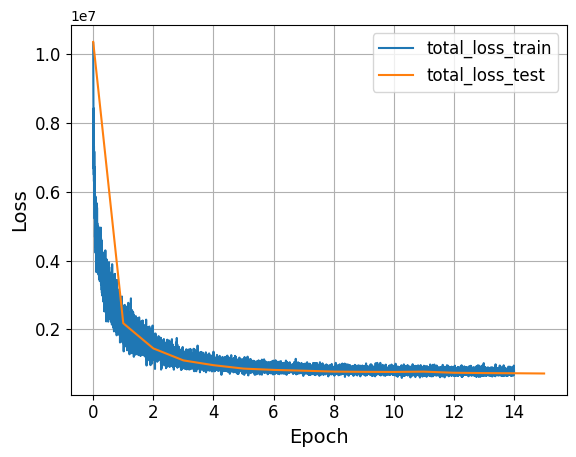

End of the training


In [39]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 64
LR = 2e-4
EPOCHS = 15
HIDDEN_CHANNELS = 64
CHANNEL_MULTIPLIERS = [1,2]
NUM_BLOCKS = 2

sigma_max = 1
sigma_min = 0.01
L = 20
SIGMAS = np.geomspace(sigma_max, sigma_min, num=L).tolist()
# ====

train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

ncsn = NoiseConditionedScoreNetwork(
    input_shape=(1, 14, 14), sigmas=SIGMAS,
    hidden_channels=HIDDEN_CHANNELS,
    channel_multipliers=CHANNEL_MULTIPLIERS,
    num_blocks=NUM_BLOCKS
)

# choose any optimizer/scheduler as you want
optimizer = torch.optim.AdamW(ncsn.parameters(), lr=LR, betas=(0.9, 0.999), weight_decay=1e-3)

# train
train_model(
    ncsn,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    n_samples=16,
    visualize_samples=False 
)

Now you can try to select proper inference parameters to obtain better images.

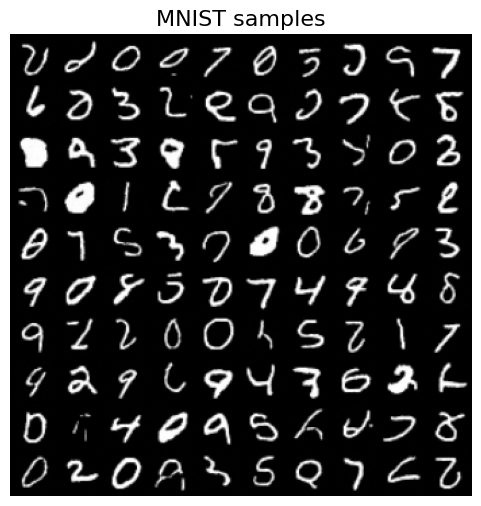

In [ ]:
# ====
# your code
# choose these parameters
NUM_STEPS = 1000
EPS = 0.1
# ====

samples = ncsn.sample(100, num_steps=NUM_STEPS, eps=EPS).cpu()
show_samples(samples, "MNIST samples")